# GloBus tutorial

A teaching example that follows **one building stream — urban detached houses in China**. The code is taken from the full multi-region GloBus model and reduced to this single stream so the logic chain stays easy to follow.

**Attribution:** This tutorial is adapted from the original GloBus model.
- Zhong, X., Deetman, S., Tukker, A., & Behrens, P. (2022). *Increasing material efficiencies of buildings to address the global sand crisis.* Nature Sustainability, 5(5), 389–392. https://doi.org/10.1038/s41893-022-00857-0
- Repo: https://github.com/Zh-xy/GloBus

## Step 1: Configuration & imports

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import os
import sys
workspace_path = os.path.abspath("..")
sys.path.insert(0, os.path.join(workspace_path, "notebook", "asset", "script"))
from dynamic_stock_model import DynamicStockModel as DSM

In [2]:
# Self-contained: run from the GloBus/ folder (inputs in data/, ODYM engine alongside).
DATA = Path('../data').resolve()

# ===== scope =====
REGION = 20                                         # 20 = China (IMAGE 3.0 region)
AREAS  = ['Urban', 'Rural']                         # keep the full urban/rural split
TYPES  = ['Detached', 'Semi-detached', 'Appartments', 'High-rise']   # 4 residential types

# =================

# full GloBus model horizon, including the pre-1971 spin-up tail
YEARS  = np.arange(1721, 2061)
years_ramp                = np.arange(1721, 1820)   # 1721-1819: linear ramp from ~0 (DSM spin-up)
years_backcast            = np.arange(1820, 1970)   # 1820-1969: reconstructed past (1970 onward = known IMAGE data)
years_backcast_floor_area = np.arange(1820, 1971)   # 1820-1970: floor area has no 1970 value (its IMAGE starts at 1971)

# the 4 types are spelled differently across the input files; map each spelling
population_share_columns = ['Detached', 'Semi-detached', 'Appartment', 'High-rise']   # population_share_by_building_type.csv columns
floor_area_per_capita_columns = ['1', '2', '3', '4']                                       # floorspace_per_capita_by_building_type.csv columns (same order)
region_column = str(REGION)

print(f'Region {REGION} (China) | areas {AREAS} | {len(AREAS)*len(TYPES)} residential streams')

Region 20 (China) | areas ['Urban', 'Rural'] | 8 residential streams


## Step 2: Prepare population data

Read the region's **population** (IMAGE, 1970–2060) and **urban/rural share**, then build the pre-1971 **spin-up tail** the DSM needs. The helpers `ramp` and `make_tail` defined here are reused in Step 3.

In [3]:
# population (millions): load the ready-made annual series (already cleaned & interpolated, 1970-2060)
population_1970_2060 = pd.read_csv(DATA/'total_population.csv', index_col=0)[region_column]
urban_population_1970_2060 = pd.read_csv(DATA/'urban_population.csv', index_col=0)[region_column]
rural_population_1970_2060 = pd.read_csv(DATA/'rural_population.csv', index_col=0)[region_column]
rural_share_1970_2060 = rural_population_1970_2060 / population_1970_2060
urban_share_1970_2060  = 1 - rural_share_1970_2060

In [4]:
print(f'2020 — population {population_1970_2060.loc[2020]:.0f} M | urban share {urban_share_1970_2060.loc[2020]:.3f}')

2020 — population 1420 M | urban share 0.550


### Spin-up tail (1721–1969): warming up the DSM

The DSM needs ~1–2 building lifetimes of history before 1971, or the first modelled year shows a false demolition spike. So each driver is extended back:
- **1820–1969** — population from the **Maddison** series; urban/rural share back-cast from the region's 1970→1980 trend (capped at the global-max rural share).
- **1721–1819** — a linear **ramp to ~0** (no cold-start spike).

`ramp` and `make_tail` assemble the full 1721–2060 series.

In [5]:
# ---------- 1721-1819: linear ramp to zero ----------
ramp = lambda v: pd.Series(np.maximum(0.0, v - v/100 * (1820 - years_ramp)), index=years_ramp)

# ---------- stitch ramp + back-cast + IMAGE into the full 1721-2060 series ----------
def make_tail(historical_segment, image_segment):
    return pd.concat([ramp(historical_segment.loc[1820]), historical_segment, image_segment]).reindex(YEARS)

In [6]:
# ---------- 1820-1969 back-cast (1970 onward is known IMAGE data) ----------
# population: Maddison fraction-of-1970 × the actual 1970 population (Maddison ends at 1969 here)
maddison_population_index = pd.read_csv(DATA/'historical_population_index_maddison.csv', index_col=0)[region_column]
population_1820_1969 = maddison_population_index.loc[1820:1969] * population_1970_2060.loc[1970]

# rural share: back-cast from the 1970->1980 trend, capped at the global-max rural share
global_total_population_1970_2060 = pd.read_csv(DATA/'total_population.csv', index_col=0)
global_rural_population_1970_2060 = pd.read_csv(DATA/'rural_population.csv', index_col=0)
gloabl_rural_share_1970_2060 = global_rural_population_1970_2060 / global_total_population_1970_2060
max_rural_share  = gloabl_rural_share_1970_2060.to_numpy().max()

rural_share_trend = (1 - rural_share_1970_2060.loc[1980] / rural_share_1970_2060.loc[1970]) / 10 * 100      # %/yr increase
rural_share_1820_1969 = pd.Series(np.minimum(max_rural_share, rural_share_1970_2060.loc[1970] * ((100 + rural_share_trend)/100) ** (1970 - years_backcast)), index=years_backcast)
urban_share_1820_1969 = 1 - rural_share_1820_1969

In [7]:
# stitch ramp + back-cast + IMAGE into the full 1721-2060 population & urban/rural share series
population_1721_2060  = make_tail(population_1820_1969, population_1970_2060)
urban_share_1721_2060 = make_tail(urban_share_1820_1969, urban_share_1970_2060)
rural_share_1721_2060 = make_tail(rural_share_1820_1969, rural_share_1970_2060)

**Wave 1 — the 1820–1969 back-cast.** Population is reconstructed back to 1820 (Maddison fraction-of-1970 × the 1970 value) and stitched onto the IMAGE data. *(Shares and floor area per capita get the same treatment.)*

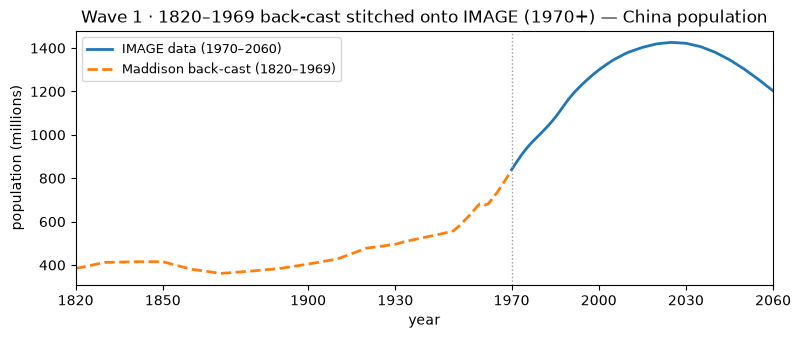

In [8]:
fig = plt.figure(figsize=(9, 3.3))
ax1 = plt.subplot(111)
population_1970_2060.plot(lw=2, label='IMAGE data (1970–2060)', ax=ax1)
population_1820_1969.plot(lw=2, ls='--', label='Maddison back-cast (1820–1969)', ax=ax1)
ax1.axvline(1970, color='0.6', ls=':', lw=1)
ax1.set_xlabel('year')
ax1.set_ylabel('population (millions)')
ax1.set_xlim(1820, 2060)
ax1.set_xticks([1820, 1850, 1900, 1930, 1970, 2000, 2030, 2060])
ax1.legend(fontsize=9)
ax1.set_title('Wave 1 · 1820–1969 back-cast stitched onto IMAGE (1970+) — China population')
plt.show()

**Wave 2 — the 1721–1819 ramp to zero.** The back-cast is extended to ~0 in 1721 so the DSM starts from an empty stock. Full 1721–2060 series, colour-coded by segment:

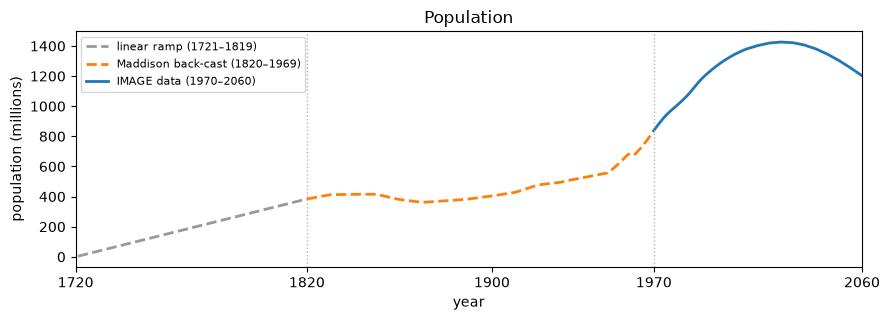

In [9]:
# Wave 2: the full 1721–2060 series after adding the linear ramp (population)
fig, ax = plt.subplots(figsize=(9, 3.3))
ramp_seg  = population_1721_2060.loc[1721:1820]    # +1yr overlap so segments connect visually
hist_seg  = population_1721_2060.loc[1820:1970]
image_seg = population_1721_2060.loc[1970:2060]
ax.plot(ramp_seg.index,  ramp_seg.values,  color='0.6', lw=2, ls='--', label='linear ramp (1721–1819)')
ax.plot(hist_seg.index,  hist_seg.values,  color='C1', lw=2, ls='--', label='Maddison back-cast (1820–1969)')
ax.plot(image_seg.index, image_seg.values, color='C0', lw=2, label='IMAGE data (1970–2060)')
for yr in (1820, 1970):
    ax.axvline(yr, color='0.7', ls=':', lw=1)

ax.set_xlim(1720, 2060)
ax.set_xticks([1720, 1820, 1900, 1970, 2060])
ax.set_xlabel('year')
ax.set_ylabel('population (millions)')
ax.set_title('Population')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
# population checkpoint on the assembled 1721–2060 series
print(f'population (M)  1850={population_1721_2060.loc[1850]:.0f}  1971={population_1721_2060.loc[1971]:.0f}  2060={population_1721_2060.loc[2060]:.0f}')

population (M)  1850=415  1971=860  2060=1202


## Step 3: Prepare floor area per capita data

Same treatment for **floor area per capita** (m²/cap, urban & rural), reusing `ramp` / `make_tail` from Step 2. Floor area has no historical data, so its pre-1971 part is a **trend back-cast** (global mean annual decline, floored at the global min). Its IMAGE series starts in 1971, so the reconstruction runs 1820–1970.

In [11]:
# floor-area per capita (m²/cap), urban & rural — load the ready-made pivoted tables (year × region, 1971-2060)
floorarea_per_cap_urban_1971_2060 = pd.read_csv(DATA/'residential_floorarea_per_capita_urban.csv', index_col=0)[region_column]
floorarea_per_cap_rural_1971_2060 = pd.read_csv(DATA/'residential_floorarea_per_capita_rural.csv', index_col=0)[region_column]

In [12]:
print(f'2020 — floor area urban {floorarea_per_cap_urban_1971_2060.loc[2020]:.1f} / rural {floorarea_per_cap_rural_1971_2060.loc[2020]:.1f} m²/cap')

2020 — floor area urban 41.3 / rural 54.2 m²/cap


In [13]:
# floor area per cap: back-cast by the GLOBAL mean annual decline, floored at the global min.
# NB: floorarea IMAGE data starts only in 1971 (no 1970), so this reconstruction runs 1820-1970.
def floor_area_backcast(urban_or_rural, floorarea_1971_2060):
    floorarea_all = pd.read_csv(DATA/ f'residential_floorarea_per_capita_{urban_or_rural}.csv', index_col=0)
    ratio    = floorarea_all.loc[1971:1980].to_numpy() / floorarea_all.loc[1972:1981].to_numpy()
    floor_area_trend = (1 - ratio.mean()) * 100                                            # %/yr decline (global)
    results = pd.Series(np.maximum(floorarea_all.to_numpy().min(),
                     floorarea_1971_2060.loc[1971] * ((100 - floor_area_trend)/100) ** (1971 - years_backcast_floor_area)), index=years_backcast_floor_area)
    return results

In [14]:
floorarea_per_cap_urban_1820_1970 = floor_area_backcast('urban', floorarea_per_cap_urban_1971_2060)
floorarea_per_cap_rural_1820_1970 = floor_area_backcast('rural', floorarea_per_cap_rural_1971_2060)

In [15]:
# stitch ramp + back-cast + IMAGE into the full 1721-2060 floor-area-per-capita series
floorarea_per_cap_urban_1721_2060 = make_tail(floorarea_per_cap_urban_1820_1970, floorarea_per_cap_urban_1971_2060)
floorarea_per_cap_rural_1721_2060 = make_tail(floorarea_per_cap_rural_1820_1970, floorarea_per_cap_rural_1971_2060)

**Floor-area-per-capita tail** (urban & rural); line style marks each segment.

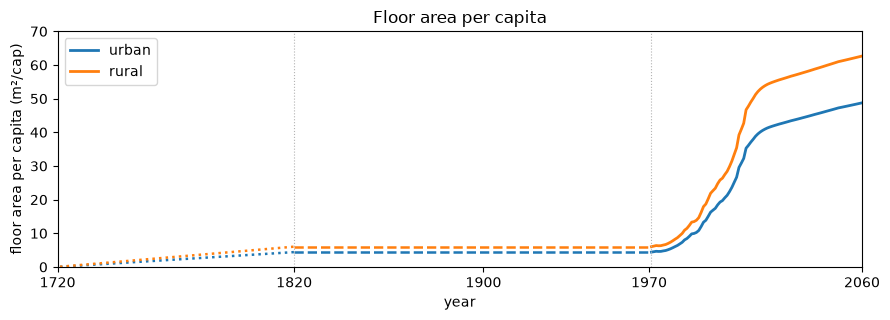

In [16]:
# floor-area-per-capita tail (urban & rural): dotted=ramp, dashed=trend back-cast, solid=IMAGE
fig = plt.figure(figsize=(9, 3.3))

ax1 = plt.subplot(111)
for series, color, name in [(floorarea_per_cap_urban_1721_2060, 'C0', 'urban'), (floorarea_per_cap_rural_1721_2060, 'C1', 'rural')]:
    ax1.plot(series.loc[1721:1820].index, series.loc[1721:1820].values, color=color, lw=1.8, ls=':')   # ramp
    ax1.plot(series.loc[1820:1971].index, series.loc[1820:1971].values, color=color, lw=1.8, ls='--')  # back-cast
    ax1.plot(series.loc[1971:2060].index, series.loc[1971:2060].values, color=color, lw=2,   label=name)  # IMAGE

for yr in (1820, 1971):
    ax1.axvline(yr, color='0.7', ls=':', lw=.8)

ax1.set_xlim(1720, 2060)
ax1.set_xticks([1720, 1820, 1900, 1970, 2060])
ax1.set_ylim(0, 70)
ax1.set_xlabel('year')
ax1.set_ylabel('floor area per capita (m²/cap)')
ax1.set_title('Floor area per capita')
ax1.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Step 4: Split the shares of different building types

Within an area, floor area is divided among the 4 building types by a **time-invariant share** combining population share and m²/cap:

$$\text{type share}_{a,t} \;=\; \frac{(\text{population share}_{a,t}) \times (\text{m}^2/\text{cap}_{a,t})}{\sum_{t'} (\text{population share}_{a,t'}) \times (\text{m}^2/\text{cap}_{a,t'})}$$

This version follows only the **urban · Detached** stream, so we compute just the urban split (the 4 shares sum to 1).

In [17]:
population_shares = pd.read_csv(DATA/'population_share_by_building_type.csv')
floorarea_per_capita = pd.read_csv(DATA/'floorarea_per_capita_by_building_type.csv')

In [18]:
# Urban — floor-area share per building type (normalised population share × m²/cap; the 4 sum to 1)
urban_population_share = population_shares.loc[(population_shares.Region == REGION) & (population_shares.Area == 'Urban'),
                                              population_share_columns].iloc[0].astype(float).to_numpy()
urban_floor_area_per_capita = floorarea_per_capita.loc[(floorarea_per_capita.Region == REGION) & (floorarea_per_capita.Area == 'Urban'),
                                                        floor_area_per_capita_columns].iloc[0].astype(float).to_numpy()
weights_urban = (urban_population_share / urban_population_share.sum()) * urban_floor_area_per_capita
weights_urban = weights_urban / weights_urban.sum()

# the four constant urban floor-area shares (sum to 1)
urban_detached_share      = weights_urban[0]
urban_semi_detached_share = weights_urban[1]
urban_appartments_share   = weights_urban[2]
urban_high_rise_share     = weights_urban[3]

In [19]:
print('urban floor-area shares by type (sum to 1):')
print(pd.Series({'Detached': urban_detached_share, 'Semi-detached': urban_semi_detached_share, 'Appartments': urban_appartments_share, 'High-rise': urban_high_rise_share}).round(3))

urban floor-area shares by type (sum to 1):
Detached         0.251
Semi-detached    0.291
Appartments      0.254
High-rise        0.205
dtype: float64


## Step 5: Develop stock model to calculate inflow and outflow

Stock = population × urban share × floor area per cap × urban-detached share (Step 4). The DSM turns this stock into annual **build** (inflow) and **demolish** (outflow).

In [20]:
area, building_type = 'Urban', 'Detached'   # the single stream this version models
n_years = len(YEARS)

In [21]:
# floor-area stock (Mm²) for the urban-detached stream
floorarea_stock = population_1721_2060 * urban_share_1721_2060 * floorarea_per_cap_urban_1721_2060 * urban_detached_share

In [22]:
lifetimes = pd.read_csv(DATA/'building_lifetimes.csv')

In [23]:
lifetimes[(lifetimes['Region'] == REGION) & (lifetimes['Area'] == 'Urban')]

,Region,Building_type,Area,Shape,Scale
152,20,Detached,Urban,2.0,33.851375
153,20,Semi-detached,Urban,2.0,39.493271
154,20,Appartments,Urban,2.0,53.598010
155,20,High-rise,Urban,2.0,56.418958


In [24]:
lifetime_row = lifetimes[(lifetimes['Region'] == REGION) & (lifetimes['Area'] == 'Urban') & (lifetimes['Building_type'] == 'Detached')]

In [25]:
param_shape = lifetime_row['Shape'].values[0]
param_scale = lifetime_row['Scale'].values[0]

In [26]:
dsm = DSM(t=np.arange(n_years), s=floorarea_stock.values,
          lt={'Type': 'Weibull',
              'Shape': np.full(n_years, param_shape),
              'Scale': np.full(n_years, param_scale)})

In [27]:
stock_cohort, outflow_cohort, inflow = dsm.compute_stock_driven_model(NegativeInflowCorrect=True)

In [28]:
outflow_cohort[outflow_cohort < 0] = 0   # clip numerical-noise negative outflow

In [29]:
floorarea_inflow  = pd.Series(inflow, index=YEARS)                                   # build    (Mm²/yr)
floorarea_outflow = pd.Series(outflow_cohort.sum(axis=1), index=YEARS).clip(lower=0)  # demolish (Mm²/yr)
print(f'2020 urban-detached build = {floorarea_inflow.loc[2020]:.0f} Mm²/yr')

2020 urban-detached build = 351 Mm²/yr


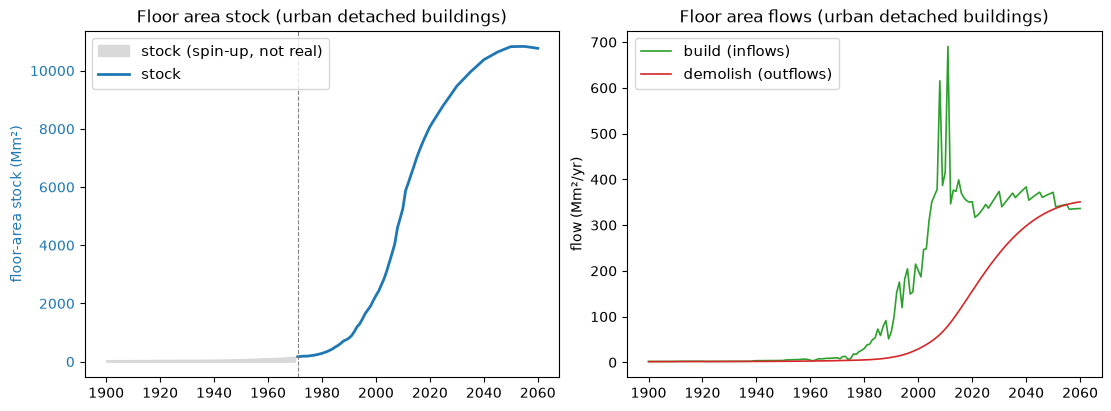

In [30]:
fig = plt.figure(figsize=(11, 4), constrained_layout=True)

ax1 = plt.subplot(121)
ax1.fill_between(np.arange(1900, 1971), floorarea_stock.loc[1900:1970], color='0.85', label='stock (spin-up, not real)')
ax1.plot(floorarea_stock.loc[1971:2060].index, floorarea_stock.loc[1971:2060], color='C0', lw=2, label='stock')
ax1.set_ylabel('floor-area stock (Mm²)', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax1.axvline(1971, color='0.5', ls='--', lw=.8)
h1, l1 = ax1.get_legend_handles_labels()
ax1.legend(h1, l1, fontsize=11, loc='upper left')
ax1.set_title('Floor area stock (urban detached buildings)')

ax2 = plt.subplot(122)
ax2.plot(floorarea_inflow.loc[1900:2060].index,  floorarea_inflow.loc[1900:2060],  color='C2', lw=1.2, label='build (inflows)')
ax2.plot(floorarea_outflow.loc[1900:2060].index, floorarea_outflow.loc[1900:2060], color='C3', lw=1.2, label='demolish (outflows)')
ax2.set_ylabel('flow (Mm²/yr)')
ax2.set_title('Floor area flows (urban detached buildings)')
h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h2,l2, fontsize=11, loc='upper left')

plt.show()

## Step 6: Convert floor area flows into concrete flows

Concrete flow = floor-area flow × the **Detached** concrete intensity (kg/m²).

In [31]:
building_materials = pd.read_csv(DATA/'material_intensity_by_building_type.csv')

In [32]:
building_materials

,Region,Building_type,concrete,glass
0,1,Detached,876.71,2.68
1,1,Semi-detached,1208.13,1.07
2,1,Appartments,995.92,6.35
3,1,High-rise,1040.35,1.20
4,2,Detached,472.10,3.32
...,...,...,...,...
99,25,High-rise,910.21,4.42
100,26,Detached,846.33,2.68
101,26,Semi-detached,1208.13,1.07
102,26,Appartments,995.92,6.35


In [33]:
building_materials[(building_materials.Region == REGION) & (building_materials.Building_type == 'Detached')]

,Region,Building_type,concrete,glass
76,20,Detached,2613.94,7.82


In [34]:
concrete_intensity_detached = building_materials[(building_materials.Region == REGION) & (building_materials.Building_type == 'Detached')]['concrete'].values[0]

In [35]:
concrete_inflow  = floorarea_inflow  * concrete_intensity_detached # Mkg/yr
concrete_outflow = floorarea_outflow * concrete_intensity_detached

In [36]:
print(f'Detached concrete intensity = {concrete_intensity_detached:.0f} kg/m²')
print(f'2020 urban-detached concrete demand = {concrete_inflow.loc[2020]:,.0f} Mkg')

Detached concrete intensity = 2614 kg/m²
2020 urban-detached concrete demand = 918,151 Mkg


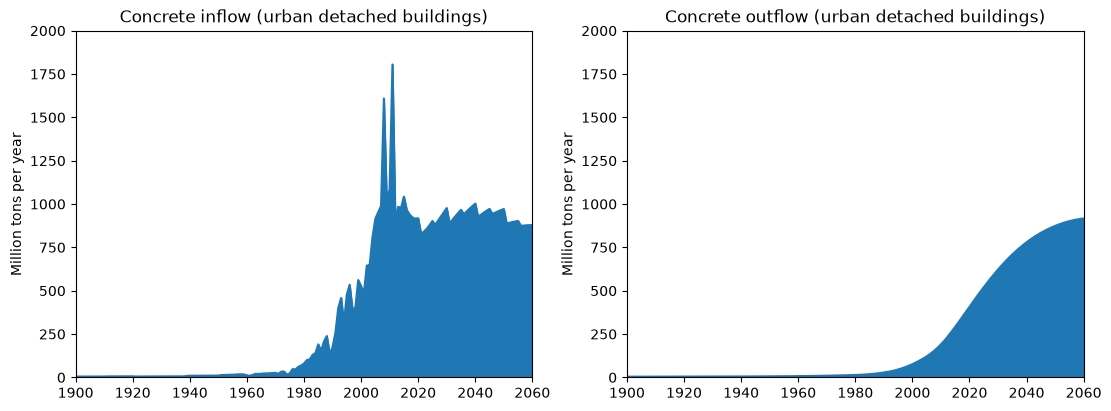

In [37]:
fig = plt.figure(figsize=(11, 4), constrained_layout=True)

ax1 = plt.subplot(121)
(concrete_inflow/1e3).plot.area(ax=ax1)
ax1.set_title('Concrete inflow (urban detached buildings)')
ax1.set(xlim=(1900, 2060), ylim=(0, 2e3), ylabel='Million tons per year')

ax2 = plt.subplot(122)
(concrete_outflow/1e3).plot.area(ax=ax2)
ax2.set_title('Concrete outflow (urban detached buildings)')
ax2.set(xlim=(1900, 2060), ylim=(0, 2e3), ylabel='Million tons per year')

plt.show()

## Step 7: Convert concrete flows into cement flows

**Cement = concrete × cement-content factor** (≈ 0.13 kg cement / kg concrete; set 1.0 for the raw concrete proxy).

In [38]:
cement_content_factor = 0.13     # kg cement / kg concrete

In [39]:
cement_inflow  = concrete_inflow  * cement_content_factor   # Mkg/yr
cement_outflow = concrete_outflow * cement_content_factor

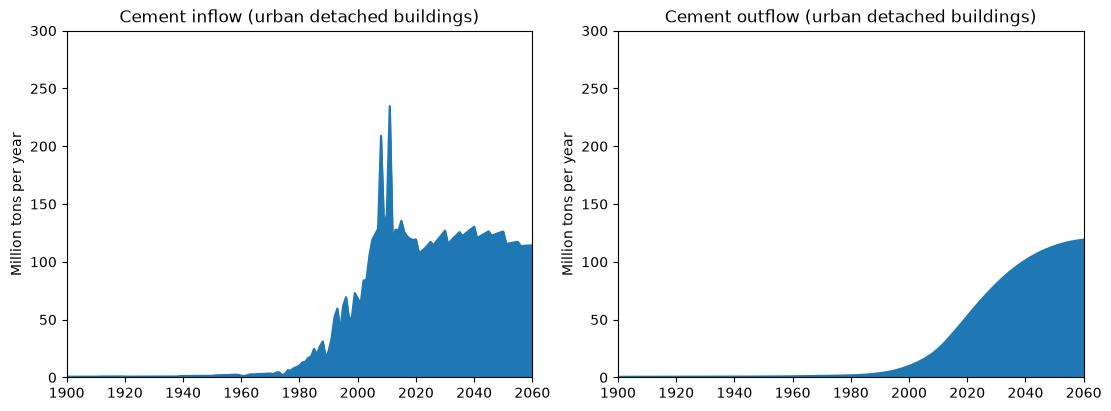

In [40]:
fig = plt.figure(figsize=(11, 4), constrained_layout=True)

ax1 = plt.subplot(121)
(cement_inflow/1e3).plot.area(ax=ax1)
ax1.set_title('Cement inflow (urban detached buildings)')
ax1.set(xlim=(1900, 2060), ylim=(0, 3e2), ylabel='Million tons per year')

ax2 = plt.subplot(122)
(cement_outflow/1e3).plot.area(ax=ax2)
ax2.set_title('Cement outflow (urban detached buildings)')
ax2.set(xlim=(1900, 2060), ylim=(0, 3e2), ylabel='Million tons per year')

plt.show()

## Step 8: Apply material efficiency (ME) levers

Four demand-side ME levers on the urban-detached stream, each **phased in linearly 2020→2060** (BAU = no change before 2020):

- **ME1 — more intensive use:** less floor area per capita (`intensive_rate = 0.93`, 7% lower).
- **ME2 — lifetime extension:** longer Weibull `Scale` (`70/30 ≈ 2.33×`, ~30 → ~70 yr).
- **ME3 — lightweight design:** less concrete per m² of new build (`reduction = 0.10`).
- **ME4 — EoL recycling:** recycled cement offsets primary demand (rate → `0.15`).

Each lever is shown alone vs BAU, then all four combined.

In [41]:
# BAU reference = the flows already computed end-to-end above, aliased with a _BAU suffix (not recomputed).
floorarea_inflow_BAU  = floorarea_inflow      # new build   (Mm2/yr)
floorarea_outflow_BAU = floorarea_outflow     # demolish    (Mm2/yr)
concrete_inflow_BAU   = concrete_inflow       # concrete inflow  (Mkg/yr)
concrete_outflow_BAU  = concrete_outflow      # concrete outflow (Mkg/yr)
cement_inflow_BAU     = cement_inflow         # primary cement demand         (Mkg/yr)
cement_outflow_BAU    = cement_outflow        # demolition cement, fed to ME4  (Mkg/yr)

scale_BAU = np.full(n_years, param_scale)     # baseline Weibull Scale, reused by ME1

print(f'BAU 2020 cement {cement_inflow_BAU.loc[2020]:,.0f} Mkg  (= Step 6 result, no re-run needed)')

BAU 2020 cement 119,360 Mkg  (= Step 6 result, no re-run needed)


In [42]:
# shared phase-in window for all ME levers (each keeps its own parameter in its section)
ME_START, ME_END = 2020, 2060
# phase-in weight: 0 before ME_START, rising linearly to 1 at ME_END
phase_in = np.clip((YEARS - ME_START) / (ME_END - ME_START), 0.0, 1.0)

### 8.1 · ME1 — more intensive use

Scale floor area per capita from 1.0 (2020) down to `intensive_rate` (0.93) by 2060. Less floor area → smaller stock → less build → less cement.

In [43]:
# ME1 lever: floor area per capita scaled by 1.0 -> intensive_rate across 2020-2060
intensive_rate = 0.93                    # ME1: floor area per capita ends 7% lower
intensive_factor = 1 + (intensive_rate - 1) * phase_in
floorarea_per_cap_urban_ME1 = floorarea_per_cap_urban_1721_2060 * intensive_factor
print(f'urban floor area per cap 2060 - BAU {floorarea_per_cap_urban_1721_2060.loc[2060]:.1f} -> ME1 {floorarea_per_cap_urban_ME1.loc[2060]:.1f} m2/cap')

urban floor area per cap 2060 - BAU 48.8 -> ME1 45.3 m2/cap


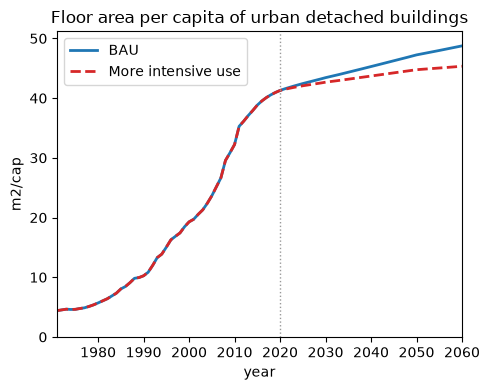

In [44]:
# visualize the ME1 lever on floor area per capita
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(YEARS, floorarea_per_cap_urban_1721_2060, color='C0', lw=2, label='BAU')
ax.plot(YEARS, floorarea_per_cap_urban_ME1, color='C3', lw=2, ls='--', label='More intensive use')
ax.axvline(ME_START, color='0.6', ls=':', lw=1)
ax.set_xlim(1971, 2060)
ax.set_ylim(0, None)
ax.set_xlabel('year')
ax.set_ylabel('m2/cap')
ax.set_title('Floor area per capita of urban detached buildings')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [45]:
# ME1 run - same pipeline as BAU, but driven by the reduced floor area per capita (Scale unchanged)
stock_ME1 = population_1721_2060 * urban_share_1721_2060 * floorarea_per_cap_urban_ME1 * urban_detached_share
dsm_ME1 = DSM(t=np.arange(n_years), s=stock_ME1.values,
              lt={'Type': 'Weibull',
                  'Shape': np.full(n_years, param_shape),
                  'Scale': np.asarray(scale_BAU, dtype=float)})
_, outflow_cohort_ME1, inflow_ME1 = dsm_ME1.compute_stock_driven_model(NegativeInflowCorrect=True)
outflow_cohort_ME1[outflow_cohort_ME1 < 0] = 0
build_ME1    = pd.Series(inflow_ME1, index=YEARS)                                    # new build (Mm2/yr)
outflow_ME1  = pd.Series(outflow_cohort_ME1.sum(axis=1), index=YEARS).clip(lower=0)  # demolish (Mm2/yr)
concrete_ME1 = build_ME1 * concrete_intensity_detached                              # concrete (Mkg/yr)
cement_ME1   = concrete_ME1 * cement_content_factor                                 # cement = concrete x content factor
print(f'2060 cement - BAU {cement_inflow_BAU.loc[2060]:,.0f} -> ME1 {cement_ME1.loc[2060]:,.0f} Mkg')

2060 cement - BAU 114,254 -> ME1 102,347 Mkg


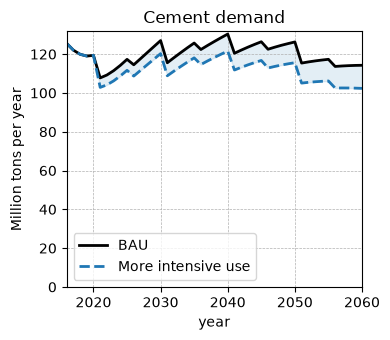

In [46]:
# cement demand: BAU vs ME1 (Mt/yr = Mkg/1e3)
yrs = slice(2016, 2060)
fig, ax = plt.subplots(figsize=(4, 3.5))
ax.plot(cement_inflow_BAU.loc[yrs].index, cement_inflow_BAU.loc[yrs]/1e3, color='k',  lw=2, label='BAU')
ax.plot(cement_ME1.loc[yrs].index, cement_ME1.loc[yrs]/1e3, color='C0', lw=2, ls='--', label='More intensive use')
ax.fill_between(cement_inflow_BAU.loc[yrs].index, cement_ME1.loc[yrs]/1e3, cement_inflow_BAU.loc[yrs]/1e3, color='C0', alpha=0.12)
ax.set_xlabel('year')
ax.set_ylabel('Million tons per year')
ax.set_xlim(2016, 2060)
ax.set_ylim(0, None)
ax.set_title('Cement demand')
ax.legend(fontsize=10)
ax.grid('on', lw=0.5, ls='--')
plt.tight_layout()
plt.show()

### 8.2 · ME2 — lifetime extension

Ramp the Weibull `Scale` up to ≈2.33× baseline by 2060. Longer-lived stock → slower demolition → less replacement build → less cement.

In [47]:
# ME2 lever: Weibull Scale ramped from baseline to lifetime_extension_rate x baseline over 2020-2060
lifetime_extension_rate = 70 / 30        # ME2: Weibull Scale ends ~2.33x longer (~30 -> ~70 yr)
scale_ME2 = param_scale * (1 + (lifetime_extension_rate - 1) * phase_in)
# mean Weibull lifetime = Scale * gamma(1 + 1/Shape); Shape=2 -> gamma(1.5) = 0.886
mean_factor = 0.886
print(f'Weibull Scale - BAU {param_scale:.1f} (~{param_scale*mean_factor:.0f} yr mean) '
      f'-> ME2 2060 {scale_ME2[-1]:.1f} (~{scale_ME2[-1]*mean_factor:.0f} yr)')

Weibull Scale - BAU 33.9 (~30 yr mean) -> ME2 2060 79.0 (~70 yr)


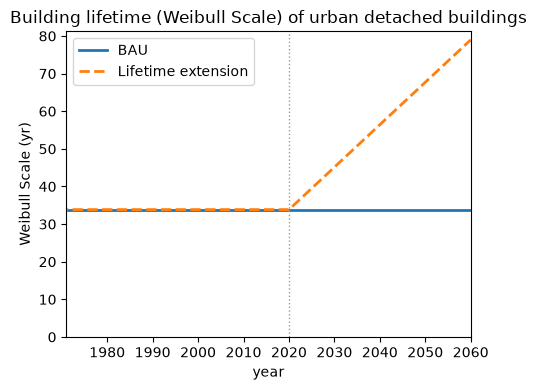

In [48]:
# visualize the ME2 lever on the Weibull Scale (characteristic lifetime)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(YEARS, np.full(n_years, param_scale), color='C0', lw=2, label='BAU')
ax.plot(YEARS, scale_ME2, color='C1', lw=2, ls='--', label='Lifetime extension')
ax.axvline(ME_START, color='0.6', ls=':', lw=1)
ax.set_xlim(1971, 2060)
ax.set_ylim(0, None)
ax.set_xlabel('year')
ax.set_ylabel('Weibull Scale (yr)')
ax.set_title('Building lifetime (Weibull Scale) of urban detached buildings')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [49]:
# ME2 run - same pipeline as BAU, but driven by the year-varying extended lifetime (Scale); floor area unchanged
stock_ME2 = population_1721_2060 * urban_share_1721_2060 * floorarea_per_cap_urban_1721_2060 * urban_detached_share
dsm_ME2 = DSM(t=np.arange(n_years), s=stock_ME2.values,
              lt={'Type': 'Weibull',
                  'Shape': np.full(n_years, param_shape),
                  'Scale': np.asarray(scale_ME2, dtype=float)})
_, outflow_cohort_ME2, inflow_ME2 = dsm_ME2.compute_stock_driven_model(NegativeInflowCorrect=True)
outflow_cohort_ME2[outflow_cohort_ME2 < 0] = 0
build_ME2    = pd.Series(inflow_ME2, index=YEARS)                                    # new build (Mm2/yr)
outflow_ME2  = pd.Series(outflow_cohort_ME2.sum(axis=1), index=YEARS).clip(lower=0)  # demolish (Mm2/yr)
concrete_ME2 = build_ME2 * concrete_intensity_detached                              # concrete (Mkg/yr)
cement_ME2   = concrete_ME2 * cement_content_factor                                 # cement = concrete x content factor
print(f'2060 cement - BAU {cement_inflow_BAU.loc[2060]:,.0f} -> ME2 {cement_ME2.loc[2060]:,.0f} Mkg')

2060 cement - BAU 114,254 -> ME2 74,389 Mkg


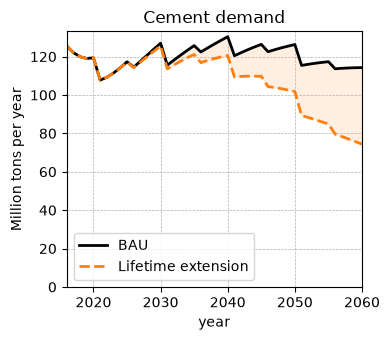

In [50]:
# cement demand: BAU vs ME2 (Mt/yr = Mkg/1e3)
yrs = slice(2016, 2060)
fig, ax = plt.subplots(figsize=(4, 3.5))
ax.plot(cement_inflow_BAU.loc[yrs].index, cement_inflow_BAU.loc[yrs]/1e3, color='k', lw=2, label='BAU')
ax.plot(cement_ME2.loc[yrs].index, cement_ME2.loc[yrs]/1e3, color='C1', lw=2, ls='--', label='Lifetime extension')
ax.fill_between(cement_inflow_BAU.loc[yrs].index, cement_ME2.loc[yrs]/1e3, cement_inflow_BAU.loc[yrs]/1e3, color='C1', alpha=0.12)
ax.set_xlabel('year')
ax.set_ylabel('Million tons per year')
ax.set_xlim(2016, 2060)
ax.set_ylim(0, None)
ax.set_title('Cement demand')
ax.legend(fontsize=10)
ax.grid('on', lw=0.5, ls='--')
plt.tight_layout()
plt.show()

### 8.3 · ME3 — lightweight design

Cut the concrete intensity of new build by `reduction` (0.10) — 1.0 (2020) → 0.90 (2060), so ~10% less concrete and cement each. Demolished stock keeps its as-built intensity.

In [51]:
# ME3 lever: cut the new-build CONCRETE intensity by `reduction`, phased in linearly over 2020-2060
reduction = 0.10                              # ME3: new-build concrete intensity ends 10% lower
concrete_factor = 1 - reduction * phase_in    # per-year factor: 1.0 (2020) -> 0.90 (2060)
print(f'concrete intensity 2060 - BAU {concrete_intensity_detached:.0f} -> ME3 {concrete_intensity_detached * concrete_factor[-1]:.0f} kg/m2')

concrete intensity 2060 - BAU 2614 -> ME3 2353 kg/m2


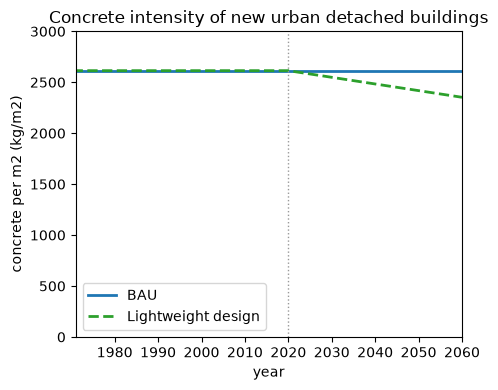

In [52]:
# visualize the ME3 lever on concrete intensity (concrete per m2)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(YEARS, np.full(n_years, concrete_intensity_detached), color='C0', lw=2, label='BAU')
ax.plot(YEARS, concrete_intensity_detached * concrete_factor, color='C2', lw=2, ls='--', label='Lightweight design')
ax.axvline(ME_START, color='0.6', ls=':', lw=1)
ax.set_xlim(1971, 2060)
ax.set_ylim(0, 3000)
ax.set_xlabel('year')
ax.set_ylabel('concrete per m2 (kg/m2)')
ax.set_title('Concrete intensity of new urban detached buildings')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [53]:
# lighter design cuts the CONCRETE intensity of new build; cement then follows via the content factor
concrete_ME3 = concrete_inflow_BAU * concrete_factor       # reduced new-build concrete (BAU floor-area flows)
cement_ME3   = concrete_ME3 * cement_content_factor        # cement = concrete x content factor
print(f'2060 cement - BAU {cement_inflow_BAU.loc[2060]:,.0f} -> ME3 {cement_ME3.loc[2060]:,.0f} Mkg')

2060 cement - BAU 114,254 -> ME3 102,828 Mkg


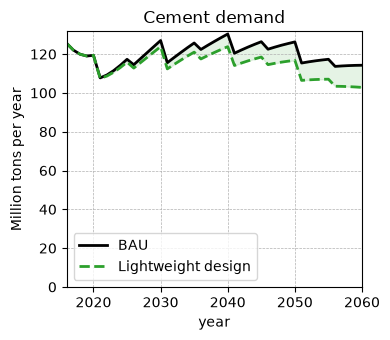

In [54]:
# cement demand: BAU vs ME3 (Mt/yr = Mkg/1e3)
yrs = slice(2016, 2060)
fig, ax = plt.subplots(figsize=(4, 3.5))
ax.plot(cement_inflow_BAU.loc[yrs].index, cement_inflow_BAU.loc[yrs]/1e3, color='k', lw=2, label='BAU')
ax.plot(cement_ME3.loc[yrs].index, cement_ME3.loc[yrs]/1e3, color='C2', lw=2, ls='--', label='Lightweight design')
ax.fill_between(cement_inflow_BAU.loc[yrs].index, cement_ME3.loc[yrs]/1e3, cement_inflow_BAU.loc[yrs]/1e3, color='C2', alpha=0.12)
ax.set_xlabel('year')
ax.set_ylabel('Million tons per year')
ax.set_xlim(2016, 2060)
ax.set_ylim(0, None)
ax.set_title('Cement demand')
ax.grid('on', lw=0.5, ls='--')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### 8.4 · ME4 — End-of-life recycling

Recover cement from demolition to offset primary demand: **net cement = inflow − outflow × recycle-rate**, the rate ramping 0 → `recycle_rate_target` (0.15) by 2060.

In [55]:
# ME4 lever: recycle/reuse rate ramps 0 -> recycle_rate across 2020-2060
recycle_rate_target = 0.15            # ME4: 15% of demolition cement recycled/reused by 2060
recycle_rate = recycle_rate_target * phase_in
recycled_cement = cement_outflow_BAU * recycle_rate          # secondary cement supply (Mkg/yr)
print(f'2060 - demolition cement {cement_outflow_BAU.loc[2060]:,.0f} Mkg, recycled {recycled_cement.loc[2060]:,.0f} Mkg ({recycle_rate_target:.0%})')

2060 - demolition cement 119,206 Mkg, recycled 17,881 Mkg (15%)


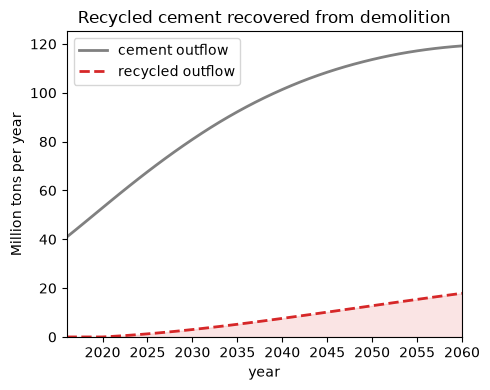

In [56]:
# visualize the ME4 secondary supply: recycled share of demolition cement
yrs = slice(2016, 2060)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(cement_outflow_BAU.loc[yrs].index, cement_outflow_BAU.loc[yrs]/1e3, color='grey', lw=2, label='cement outflow')
ax.plot(recycled_cement.loc[yrs].index, recycled_cement.loc[yrs]/1e3, color='C3', lw=2, ls='--', label='recycled outflow')
ax.fill_between(recycled_cement.loc[yrs].index, 0, recycled_cement.loc[yrs]/1e3, color='C3', alpha=0.12)
ax.set_xlabel('year')
ax.set_ylabel('Million tons per year')
ax.set_xlim(2016, 2060)
ax.set_ylim(0, None)
ax.set_title('Recycled cement recovered from demolition')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [57]:
# primary cement after EoL recycling (BAU floor-area & intensity, minus recycled supply)
cement_ME4 = cement_inflow_BAU - recycled_cement
print(f'2060 cement - BAU {cement_inflow_BAU.loc[2060]:,.0f} -> ME4 {cement_ME4.loc[2060]:,.0f} Mkg')

2060 cement - BAU 114,254 -> ME4 96,373 Mkg


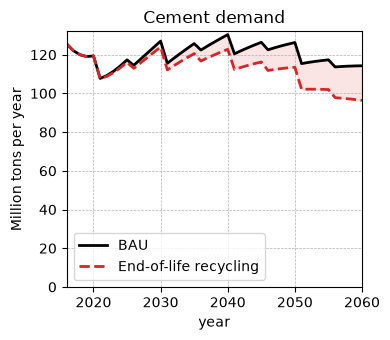

In [58]:
# cement demand: BAU vs ME4 (Mt/yr = Mkg/1e3)
yrs = slice(2016, 2060)
fig, ax = plt.subplots(figsize=(4, 3.5))
ax.plot(cement_inflow_BAU.loc[yrs].index, cement_inflow_BAU.loc[yrs]/1e3, color='k', lw=2, label='BAU')
ax.plot(cement_ME4.loc[yrs].index, cement_ME4.loc[yrs]/1e3, color='C3', lw=2, ls='--', label='End-of-life recycling')
ax.fill_between(cement_inflow_BAU.loc[yrs].index, cement_ME4.loc[yrs]/1e3, cement_inflow_BAU.loc[yrs]/1e3, color='C3', alpha=0.12)
ax.set_xlabel('year')
ax.set_ylabel('Million tons per year')
ax.set_xlim(2016, 2060)
ax.set_ylim(0, None)
ax.set_title('Cement demand')
ax.legend(fontsize=10)
ax.grid('on', lw=0.5, ls='--')
plt.tight_layout()
plt.show()

### 8.5 · All four levers & comparison

ME1+ME2 reshape the floor-area flows; ME3+ME4 then act on that scenario's cement. Compare each lever alone and all four combined, plus the **cumulative** cement over 2020–2060.

In [59]:
# ALL (ME1-4): ME1 (reduced floor area) + ME2 (extended lifetime) reshape the floor-area flows through the DSM
stock_ALL = population_1721_2060 * urban_share_1721_2060 * floorarea_per_cap_urban_ME1 * urban_detached_share
dsm_ALL = DSM(t=np.arange(n_years), s=stock_ALL.values,
              lt={'Type': 'Weibull',
                  'Shape': np.full(n_years, param_shape),
                  'Scale': np.asarray(scale_ME2, dtype=float)})
_, outflow_cohort_ALL, inflow_ALL = dsm_ALL.compute_stock_driven_model(NegativeInflowCorrect=True)
outflow_cohort_ALL[outflow_cohort_ALL < 0] = 0
inflow_ALL   = pd.Series(inflow_ALL, index=YEARS)                                    # unit: million m2/yr
outflow_ALL = pd.Series(outflow_cohort_ALL.sum(axis=1), index=YEARS).clip(lower=0)   # unit: million m2/yr

# ME3 cuts the new-build concrete intensity; ME4 recycles the cement recovered from demolition
concrete_ALL_in  = inflow_ALL   * concrete_intensity_detached * concrete_factor      # new-build concrete (lighter design)
concrete_ALL_out = outflow_ALL * concrete_intensity_detached                         # demolition concrete (as-built intensity)
cement_ALL = concrete_ALL_in * cement_content_factor - (concrete_ALL_out * cement_content_factor) * recycle_rate

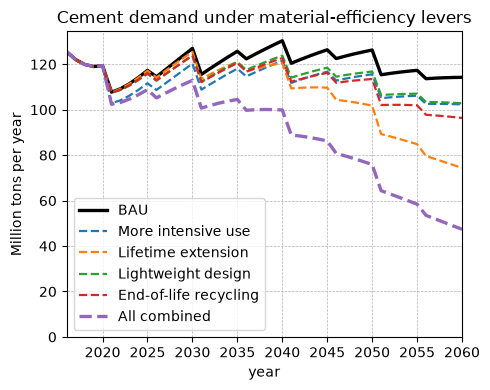

In [60]:
# cement demand: all scenarios 2016-2060 (Mt/yr)
scenarios = {'BAU': cement_inflow_BAU, 'More intensive use': cement_ME1, 'Lifetime extension': cement_ME2,
             'Lightweight design': cement_ME3, 'End-of-life recycling': cement_ME4, 'All combined': cement_ALL}
colors = {'BAU': 'k', 'More intensive use': 'C0', 'Lifetime extension': 'C1',
          'Lightweight design': 'C2', 'End-of-life recycling': 'C3', 'All combined': 'C4'}

yrs = slice(2016, 2060)
fig, ax = plt.subplots(figsize=(5, 4))
for name, series in scenarios.items():
    ax.plot(series.loc[yrs].index, series.loc[yrs]/1e3,
            lw=2.4 if name in ('BAU', 'All combined') else 1.6,
            color=colors[name], ls='-' if name == 'BAU' else '--', label=name)
ax.set_xlabel('year')
ax.set_ylabel('Million tons per year')
ax.set_xlim(2016, 2060)
ax.set_ylim(0, None)
ax.set_title('Cement demand under material-efficiency levers')
ax.legend(fontsize=10, ncol=1)
ax.grid('on', lw=0.5, ls='--')
plt.tight_layout()
plt.show()

In [61]:
# cumulative cement 2020-2060 (Mkg -> Mt: /1000) and saving vs BAU
cumulative_mt = {name: series.loc[2020:2060].sum() / 1000 for name, series in scenarios.items()}
for name, total in cumulative_mt.items():
    saving = (1 - total / cumulative_mt['BAU']) * 100
    print(f'{name:22s} cumulative 2020-2060 = {total:8,.0f} Mt cement   ({saving:5.1f}% vs BAU)')

BAU                    cumulative 2020-2060 =    4,911 Mt cement   (  0.0% vs BAU)
More intensive use     cumulative 2020-2060 =    4,568 Mt cement   (  7.0% vs BAU)
Lifetime extension     cumulative 2020-2060 =    4,345 Mt cement   ( 11.5% vs BAU)
Lightweight design     cumulative 2020-2060 =    4,665 Mt cement   (  5.0% vs BAU)
End-of-life recycling  cumulative 2020-2060 =    4,581 Mt cement   (  6.7% vs BAU)
All combined           cumulative 2020-2060 =    3,595 Mt cement   ( 26.8% vs BAU)


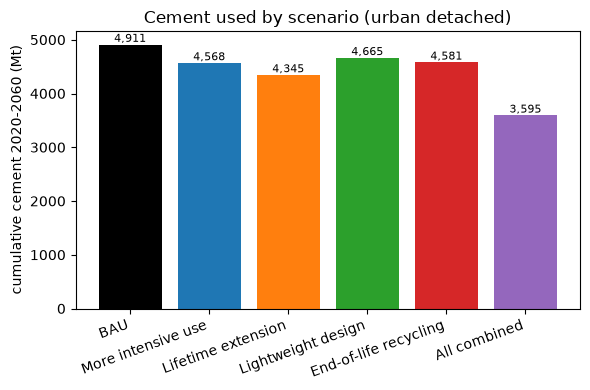

In [62]:
# bar chart of cumulative cement 2020-2060
fig, ax = plt.subplots(figsize=(6, 4))
names = list(cumulative_mt)
ax.bar(names, [cumulative_mt[n] for n in names], color=[colors[n] for n in names])
ax.set_ylabel('cumulative cement 2020-2060 (Mt)')
ax.set_title('Cement used by scenario (urban detached)')
for i, n in enumerate(names):
    ax.text(i, cumulative_mt[n], f'{cumulative_mt[n]:,.0f}', ha='center', va='bottom', fontsize=8)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()